In [1]:
import rasterio
import numpy as np
from pathlib import Path
from dem_stitcher.rio_window import get_cropped_profile
import matplotlib.pyplot as plt
from tqdm import tqdm

In [31]:
sample_metric_path = 'products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1_GEN-METRIC.tif'

In [32]:
with rasterio.open(sample_metric_path) as ds:
    X = ds.read(1)
    tags = ds.tags()

In [33]:
size = 200
y_start = 1_950
x_start = 2_150
SY = np.s_[y_start: y_start + size]
SX = np.s_[x_start: x_start + size]

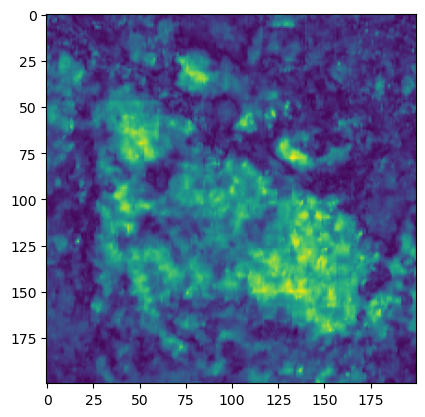

In [35]:
plt.imshow(X[SY, SX])

In [36]:
prods_without_confirmation_dir = Path('products_without_confirmation')
assert prods_without_confirmation_dir.exists()

In [37]:
prods_without_confirmation_cropped_dir = Path('products_without_confirmation_cropped')
prods_without_confirmation_cropped_dir.mkdir(exist_ok=True, parents=True)

In [38]:
def crop_one_dist_product(opera_prod_dir: Path, dst_dir: Path) -> list[Path]:
    dst_prod_dir = dst_dir / opera_prod_dir.name
    dst_prod_dir.mkdir(exist_ok=True, parents=True)
    tif_layers = list(opera_prod_dir.glob('OPERA*.tif'))
    dst_tif_layers = [dst_prod_dir / tif_layer.name for tif_layer in tif_layers]
    dst_paths = [crop_one_tif_and_serialize(tif_layer, dst_tif_layer) 
                 for (tif_layer, dst_tif_layer) in zip(tif_layers, dst_tif_layers)]
    
    return dst_paths

def crop_one_tif_and_serialize(tif_path: Path, dst_path: Path) -> list[Path]:
    with rasterio.open(tif_path) as ds:
        X_src = ds.read(1)
        p_src = ds.profile
        tags = ds.tags()
    p_c = get_cropped_profile(p_src, SX, SY)
    X_c = X[SY, SX]
    with rasterio.open(dst_path, 'w', **p_c) as ds:
        ds.write(X_c, 1)
        ds.update_tags(**tags)
    return dst_path

In [39]:
opera_prod_dirs = list(Path('products_without_confirmation').glob('OPERA*'))
opera_prod_dirs = list(filter(lambda d: d.is_dir(), opera_prod_dirs))
opera_prod_dirs

[PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240202T100430Z_20250806T143249Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240109T100431Z_20250806T141416Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240228T232836Z_20250806T145451Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240216T232836Z_20250806T144543Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240204T232836Z_20250806T143647Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240209T233645Z_20250806T143730Z_S1_30_v0.1'),
 PosixPath('products_without_confirmation/OPERA_L3_DIST-ALERT-S1_T19HBD_20240128T233646Z_20250806T142756Z_S1_30_v0.1'),
 PosixPath('products_without_confirmatio

In [40]:
[crop_one_dist_product(prod_dir, prods_without_confirmation_cropped_dir) for prod_dir in tqdm(opera_prod_dirs)]

100%|████████████████████████████████████████████████████████████| 15/15 [00:07<00:00,  2.13it/s]


[[PosixPath('products_without_confirmation_cropped/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1_GEN-DIST-DATE.tif'),
  PosixPath('products_without_confirmation_cropped/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1_GEN-METRIC.tif'),
  PosixPath('products_without_confirmation_cropped/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1_GEN-DIST-LAST-DATE.tif'),
  PosixPath('products_without_confirmation_cropped/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_20250806T144151Z_S1_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
  PosixPath('products_without_confirmation_cropped/OPERA_L3_DIST-ALERT-S1_T19HBD_20240214T100429Z_202508